In [ ]:
pip install yfinance pandas

In [ ]:
# Obtendo os dados
import yfinance as yf
import pandas as pd

ticker = "ABEV3.SA"

start_date = "2023-01-01"
end_date = "2025-12-31"

dados = yf.download(ticker, start=start_date, end=end_date)

print(dados.head())

dados.to_csv(f"{ticker}_historico.csv")

In [ ]:
# Criando o alvo
if isinstance(dados.columns, pd.MultiIndex):
    dados.columns = dados.columns.droplevel(1)

dados['Diferenca'] = dados['Close'] - dados['Open']

dados['Alvo'] = (dados['Diferenca'] > 0).astype(int)

print(dados[['Open', 'Close', 'Diferenca', 'Alvo']].head())

In [ ]:
# Separação dos dados em treino e teste
dados_treino = dados.loc['2023-01-01':'2024-12-31'].copy()
dados_teste = dados.loc['2025-01-01':'2025-12-31'].copy()

print(f"Dados Treinamento: {len(dados_treino)}")
print(f"Dados Teste: {len(dados_teste)}")

In [64]:
from sklearn.neighbors import KNeighborsClassifier

# Pistas
features = ['Open', 'High', 'Low', 'Volume']

X_treino = dados_treino[features]
y_treino = dados_treino['Alvo']

X_teste = dados_teste[features]
y_teste = dados_teste['Alvo']

modelo_knn_bruto = KNeighborsClassifier(n_neighbors=5)

modelo_knn_bruto.fit(X_treino, y_treino)

previsoes_brutas = modelo_knn_bruto.predict(X_teste)

print(f"Total de previsões geradas para 2025: {len(previsoes_brutas)}")

Total de previsões geradas para 2025: 250


In [65]:
from sklearn.preprocessing import StandardScaler

# Revisão
scaler = StandardScaler()

X_treino_norm = scaler.fit_transform(X_treino)

X_teste_norm = scaler.transform(X_teste)

modelo_knn_norm = KNeighborsClassifier(n_neighbors=5)
modelo_knn_norm.fit(X_treino_norm, y_treino)

previsões_normalizadas = modelo_knn_norm.predict(X_teste_norm)

print(f"Total de novas previsões geradas: {len(previsões_normalizadas)}")

Total de novas previsões geradas: 250


In [63]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix

# Avaliação
def avaliar_robo(nome_cenario, gabarito_real, palpites_do_robo):
    print(f"{nome_cenario}")
    
    acertos = (gabarito_real == palpites_do_robo).sum()
    erros = (gabarito_real != palpites_do_robo).sum()
    print(f"Acertos: {acertos} dias / Erros: {erros} dias")
    
    # 2 Métricas
    acuracia = accuracy_score(gabarito_real, palpites_do_robo)
    precisao = precision_score(gabarito_real, palpites_do_robo)
    f1 = f1_score(gabarito_real, palpites_do_robo)
    
    tn, fp, fn, tp = confusion_matrix(gabarito_real, palpites_do_robo).ravel()
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"Acurácia: {acuracia:.2f}")
    print(f"Precisão: {precisao:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print(f"Especificidade: {especificidade:.2f}\n")

avaliar_robo("DADOS BRUTOS", y_teste, previsoes_brutas)

avaliar_robo("DADOS NORMALIZADOS", y_teste, previsões_normalizadas)

DADOS BRUTOS
Acertos: 118 dias / Erros: 132 dias
Acurácia: 0.47
Precisão: 0.53
F1-Score: 0.37
Especificidade: 0.69

DADOS NORMALIZADOS
Acertos: 128 dias / Erros: 122 dias
Acurácia: 0.51
Precisão: 0.79
F1-Score: 0.24
Especificidade: 0.96



In [52]:
# Calculo Financeiro

dados_teste['Rendimento_Diario_%'] = ((dados_teste['Close'] - dados_teste['Open']) / dados_teste['Open']) * 100

dados_teste['Previsao_Robo'] = previsões_normalizadas

dias_operados = dados_teste[dados_teste['Previsao_Robo'] == 1]

retorno_ganhos = dias_operados[dias_operados['Rendimento_Diario_%'] > 0]['Rendimento_Diario_%'].sum()

retorno_perdas = dias_operados[dias_operados['Rendimento_Diario_%'] < 0]['Rendimento_Diario_%'].sum()

retorno_geral = retorno_ganhos + retorno_perdas

print(f"Retorno Financeiro dos Ganhos: {retorno_ganhos:.2f}%")
print(f"Retorno Financeiro das Perdas: {retorno_perdas:.2f}%")
print(f"Retorno Financeiro Geral: {retorno_geral:.2f}%\n")

Retorno Financeiro dos Ganhos: 45.45%
Retorno Financeiro das Perdas: -20.26%
Retorno Financeiro Geral: 25.19%



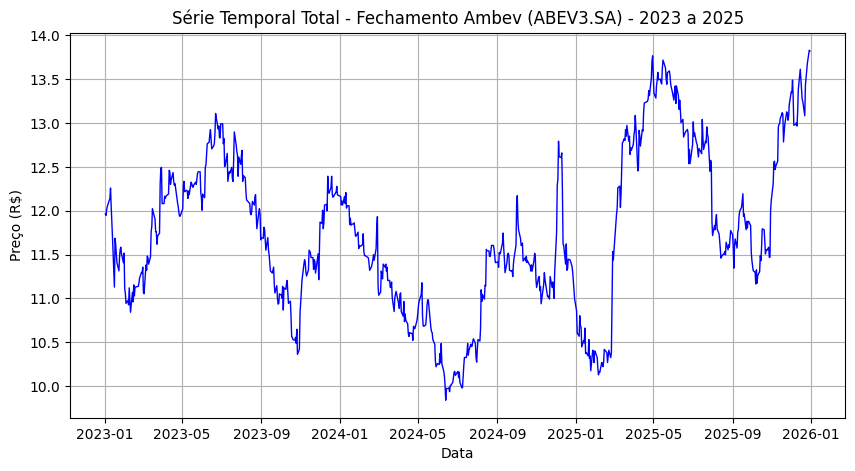

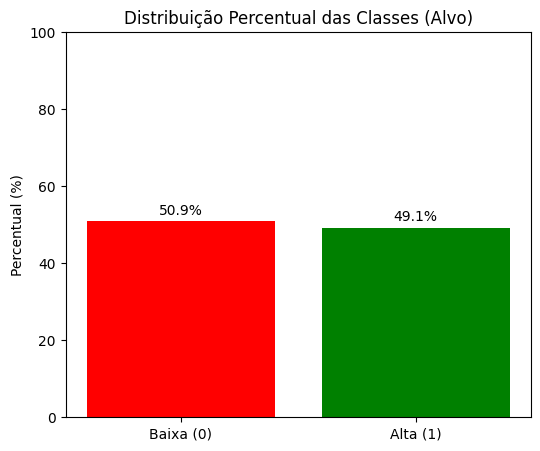

In [ ]:
import matplotlib.pyplot as plt

# Gráficos
# Gráfico de linha da série temporal total avaliada
plt.figure(figsize=(10, 5))
plt.plot(dados.index, dados['Close'], color='blue', linewidth=1)
plt.title('Série Temporal Total - Fechamento Ambev (ABEV3.SA) - 2023 a 2025')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.grid(True)
plt.savefig('grafico_serie_temporal.png')
plt.show()

# Gráfico de barras e quantitativo em percentual das classes calculadas
percentual_classes = dados['Alvo'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 5))
barras = plt.bar(['Baixa (0)', 'Alta (1)'], percentual_classes, color=['red', 'green'])
plt.title('Distribuição Percentual das Classes (Alvo)')
plt.ylabel('Percentual (%)')
plt.ylim(0, 100)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 1,
             f'{altura:.1f}%', ha='center', va='bottom')

plt.savefig('grafico_barras_classes.png')
plt.show()